In [1]:
# uncomment this if running on colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%matplotlib inline
import sys
import numpy as np
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

# SIFT - a demo

The objective of this activity is to critically analyse the results you obtain by running the code and learn about the potential of SIFT descriptors for feature matching


## First time with OpenCV?

So far we have used skimage. OpenCV has a wider range of Computational Vision pre-implemented functionalities.

Have a look at <a href="https://docs.opencv.org/master/d9/df8/tutorial_root.html" > online tutorials</a>

First, let us import the library

In [3]:
import cv2 as cv

## 1. SIFT computation and visualization

If you want to know something more click on the <a http="https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html"> SIFT OpenCV tutorial </a>




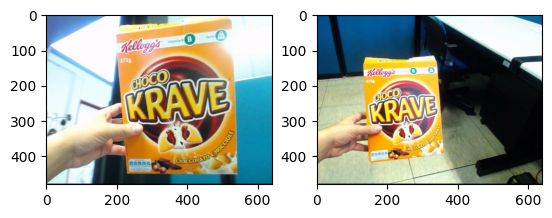

In [4]:
# simple
#img1 = cv.imread('/content/drive/MyDrive/CV_LABS/lab_Matching/lab/solution/images/shrub_L.jpg')
#img2 = cv.imread('/content/drive/MyDrive/CV_LABS/lab_Matching/lab/solution/images/shrub_R.jpg')

# harder
img1 = cv.imread('/content/drive/MyDrive/CV_LABS/lab_Matching/lab/solution/Imageset/BackgroundChange/11201.jpg')
img2 = cv.imread('/content/drive/MyDrive/CV_LABS/lab_Matching/lab/solution/Imageset/BackgroundChange/18301.jpg')


fig = plt.figure()
fig.add_subplot(1,2,1)
plt.imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB))
fig.add_subplot(1,2,2)
plt.imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))


## 2. Image matching with SIFT features

We now compute matches between SIFT features from an image pair. In the example we notice a background, illumination and scale change

### 2.1 Detection first

In [5]:
sift = cv.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)
img1_with_kp = None
img2_with_kp = None
img1_with_kp = cv.drawKeypoints(img1,kp1,img1_with_kp)
img2_with_kp = cv.drawKeypoints(img2,kp2,img2_with_kp)

In [6]:
# Converting image1 from BGR to RGB (OpenCV design)
img1_with_kp=cv.drawKeypoints(img1,kp1,img1_with_kp,flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img2_with_kp=cv.drawKeypoints(img2,kp2,img2_with_kp,flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(50, 100))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(img1_with_kp, cv.COLOR_BGR2RGB))
plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(img2_with_kp, cv.COLOR_BGR2RGB))


Output hidden; open in https://colab.research.google.com to view.

### 2.2 Matching
The  following feature matching will follow two steps:
1. Brute force matching
2. Lowe's filtering

Brute force matching is a simple: take the featue description of each feature in one image and calculate it's distance from every feature in the other image. Lowe filtering is a thresholding technique to eliminate matches with high distances.

If you have time, you may check other parameters of BFMatcher. You may try them and see how the results change!

In [7]:
# BFMatcher with default params
bf = cv.BFMatcher()

In [8]:
# Testing the top two best matches to increase matching accuracy
matches = bf.knnMatch(des1,des2, k=2)

In [9]:
# Store all the good matches as per Lowe's ratio test
good = []
for m,n in matches:
    if m.distance < 0.7*n.distance:
        good.append([m])

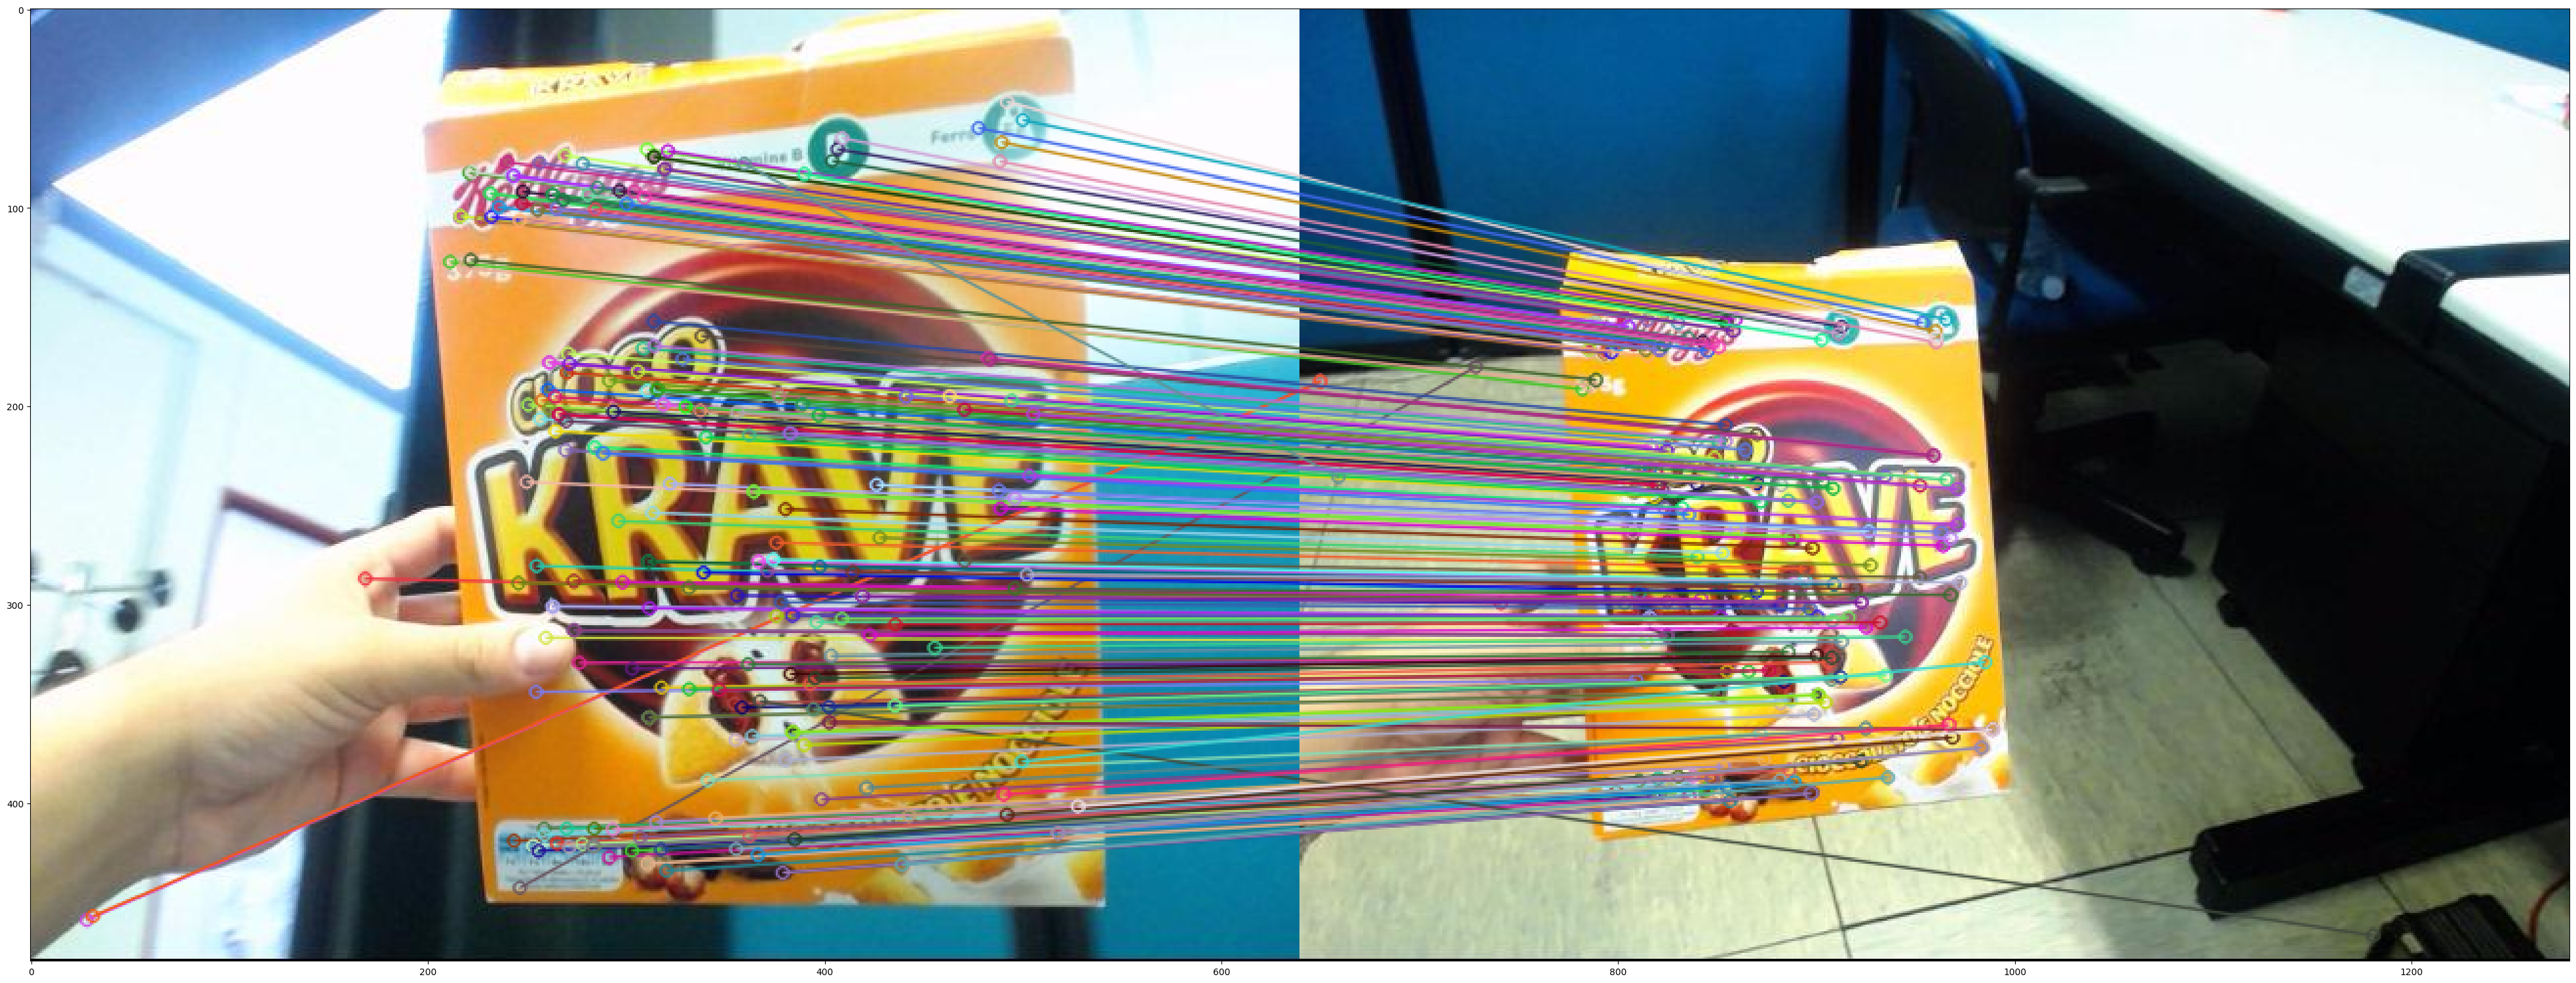

In [10]:
img3 = None
img3 = cv.drawMatchesKnn(img1,kp1,img2,kp2,good,img3,flags=2)
plt.figure(figsize=(50, 100))
plt.imshow(cv.cvtColor(img3, cv.COLOR_BGR2RGB))

Try the above with other images pairs from the sets provided. In particular, try image pairs from  
1. Imageset/2DMovement
2. Imageset/ColorChanges
3. Imageset/Random

Observe the success and failure of the two methods against different types of variations.
